In [166]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, k_means
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split


In [167]:
country = pd.read_csv(r"C:\Users\ADMIN\Downloads\Country Data.csv")

In [168]:
country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [169]:
country.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [170]:
country.isnull()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
162,False,False,False,False,False,False,False,False,False,False
163,False,False,False,False,False,False,False,False,False,False
164,False,False,False,False,False,False,False,False,False,False
165,False,False,False,False,False,False,False,False,False,False


In [171]:
country.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [172]:
X = country.select_dtypes(include=np.number)

In [173]:
# Fill missing values
X = X.fillna(X.mean())

In [174]:
# Scale numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]], shape=(167, 9))

In [175]:
print(X_scaled.shape)

(167, 9)


Kmeans

In [176]:
KMeans = KMeans(n_clusters=3,random_state=42)
label = KMeans.fit_predict(X_scaled)

In [177]:
label

array([2, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 1,
       1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2,
       2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0,
       1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 1, 1, 1, 0, 2, 1, 1, 0, 0, 2, 0, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2], dtype=int32)

In [178]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3)
model.fit(X_scaled)
KMeans_labels=model.predict(X_scaled)

In [179]:
KMeans_labels

array([0, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2,
       2, 1, 2, 0, 0, 2, 0, 1, 2, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0, 2, 1, 1,
       1, 2, 2, 2, 2, 0, 0, 2, 2, 1, 1, 0, 0, 2, 1, 0, 1, 2, 2, 0, 0, 2,
       0, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 2, 2, 0, 0, 1, 2, 0, 2, 2, 0,
       0, 2, 2, 1, 2, 0, 0, 2, 2, 0, 1, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2,
       1, 1, 0, 0, 1, 2, 0, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 2, 0, 2, 2,
       0, 1, 1, 1, 2, 0, 1, 1, 2, 2, 0, 2, 1, 1, 2, 0, 2, 0, 0, 2, 2, 2,
       2, 0, 2, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0], dtype=int32)

In [180]:
inertia = model.inertia_
silhouette_avg =silhouette_score(X,KMeans_labels)
silhouette_avg

0.23610096177701748

In [181]:
inertia=model.inertia_
silhouette_avg=silhouette_score(X,KMeans_labels)

print("\nperformance Metrics for K-Means Clustering:")
print(f"- Inertia (sum of squared distances): {inertia:.2f}")
print(f"- Silhouette Score: {silhouette_avg:.4f}")


performance Metrics for K-Means Clustering:
- Inertia (sum of squared distances): 831.44
- Silhouette Score: 0.2361


In [182]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Best K
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print("Best number of clusters:", best_k)

Best number of clusters: 5


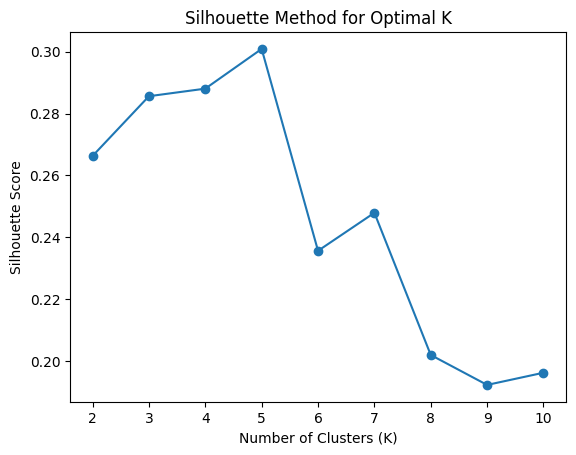

In [183]:
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.show()

In [184]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [185]:
gmm = GaussianMixture(n_components=3,random_state=42)
md = gmm.fit(X_scaled)

In [186]:
gm_pred = md.predict(X_scaled)
gm_pred

array([2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 0, 1, 2, 0, 0, 1, 2, 2, 2, 2, 0, 2,
       0, 1, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 0,
       1, 0, 0, 0, 0, 2, 2, 0, 2, 1, 1, 2, 2, 0, 1, 2, 1, 0, 2, 2, 2, 2,
       2, 0, 1, 2, 0, 0, 2, 1, 1, 1, 0, 1, 2, 0, 2, 2, 1, 2, 2, 0, 0, 2,
       2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       1, 1, 2, 2, 1, 1, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 0,
       2, 1, 0, 1, 2, 2, 1, 1, 2, 0, 2, 0, 1, 1, 2, 2, 0, 2, 2, 2, 0, 0,
       2, 2, 0, 1, 1, 1, 0, 2, 2, 0, 2, 2, 2])

In [187]:
from sklearn.cluster import DBSCAN

In [188]:
def display_categories(model,data):
    labels = model.fit_predict(data)
    sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

In [189]:
dbscan = DBSCAN()

In [194]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)
labels

array([ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,
        0,  0, -1, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,
        0,  0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0, -1, -1, -1,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0, -1,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0])

In [193]:
# Add cluster labels
country["Cluster"] = labels

# Display result
country[["country", "Cluster"]].head()



,country,Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,-1
4,Antigua and Barbuda,0


In [ ]:
# Add cluster labels
country["Cluster"] = labels

# Display result
print(country[["country", "Cluster"]].head())

# Count clusters and noise
print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", list(labels).count(-1))

               country  Cluster
0          Afghanistan        0
1              Albania        0
2              Algeria        0
3               Angola       -1
4  Antigua and Barbuda        0
Clusters: 1
Noise points: 30


In [195]:
from sklearn.decomposition import PCA

In [196]:
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X_scaled)

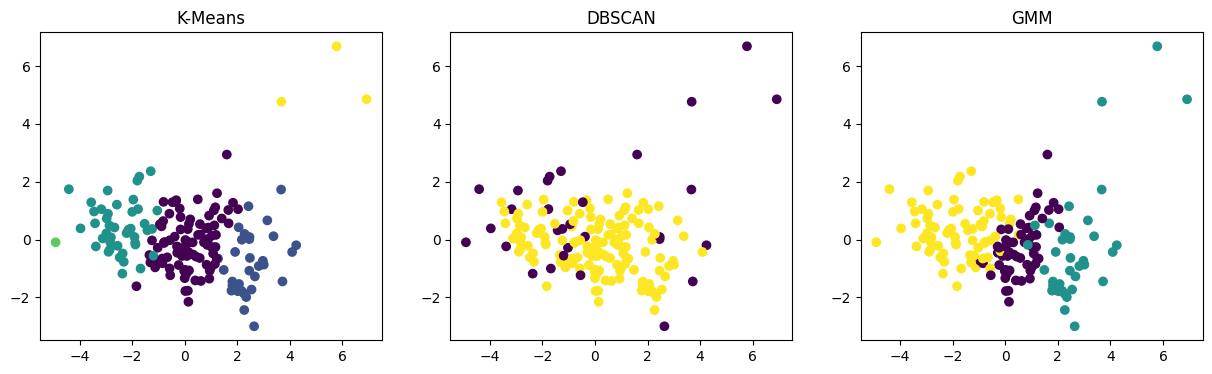

In [198]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot K-Means
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means")

# Plot DBSCAN
plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("DBSCAN")

# Plot GMM
plt.subplot(1,3,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=gm_pred)
plt.title("GMM")

plt.show()